<a href="https://colab.research.google.com/github/Ns09844/Data-Analysis-Projects/blob/healthcare/Analysis_of_Drug_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/drugs_side_effects_drugs_com.csv')

In [ ]:
print(data.shape)

(2931, 17)


In [ ]:
data.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   drug_name                      2931 non-null   object 
 1   medical_condition              2931 non-null   object 
 2   side_effects                   2807 non-null   object 
 3   generic_name                   2888 non-null   object 
 4   drug_classes                   2849 non-null   object 
 5   brand_names                    1718 non-null   object 
 6   activity                       2931 non-null   object 
 7   rx_otc                         2930 non-null   object 
 8   pregnancy_category             2702 non-null   object 
 9   csa                            2931 non-null   object 
 10  alcohol                        1377 non-null   object 
 11  related_drugs                  1462 non-null   object 
 12  medical_condition_description  2931 non-null   o

In [ ]:
data.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,124
generic_name,43
drug_classes,82
brand_names,1213
activity,0
rx_otc,1
pregnancy_category,229
csa,0


In [ ]:
data['no_of_reviews'] = pd.to_numeric(data['no_of_reviews'], errors='coerce')
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

In [ ]:
print(data.dtypes.value_counts())

object     15
float64     2
Name: count, dtype: int64


In [ ]:
data['side_effects'] = data['side_effects'].fillna('Unknown')
data['related_drugs'] = data['related_drugs'].fillna(0)

data['rating'] = data['rating'].fillna(0)        #assuming missing values
data['no_of_reviews'] = data['no_of_reviews'].fillna(0)

In [ ]:
data['activity'] = data['activity'].fillna(0)     #assuming no information
data['drug_classes'] = data['drug_classes'].fillna('Unknown')
data['generic_name'] = data['generic_name'].fillna('Unknown')
data['pregnancy_category'] = data['pregnancy_category'].fillna('Unknown')

In [ ]:
#Changing na to 0 - no interaction
data['alcohol'] = data['alcohol'].fillna(0)
#Changing X to 1
data['alcohol'] = data['alcohol'].replace({'X':1})

/tmp/ipython-input-1502174732.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['alcohol'] = data['alcohol'].replace({'X':1})


In [ ]:
data['rx_otc'] = data['rx_otc'].fillna('Unknown')

In [ ]:
data = data.drop(columns = ['brand_names'])

In [ ]:
data.isnull().sum()

,0
drug_name,0
medical_condition,0
side_effects,0
generic_name,0
drug_classes,0
activity,0
rx_otc,0
pregnancy_category,0
csa,0
alcohol,0


In [ ]:
data.describe()

,alcohol,rating,no_of_reviews
count,2931.000000,2931.000000,2931.000000
mean,0.469806,3.686557,40.618560
std,0.499173,3.797851,141.046113
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,3.300000,1.000000
75%,1.000000,7.300000,15.000000
max,1.000000,10.000000,2934.000000


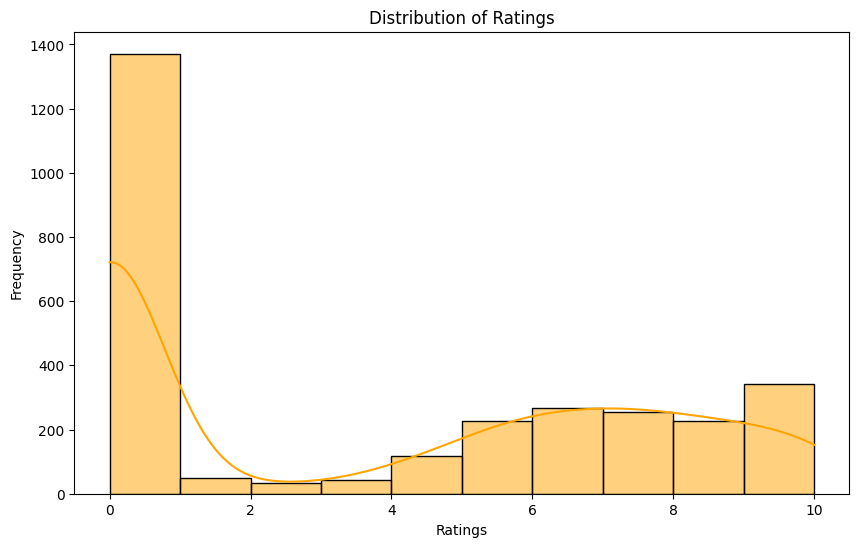

In [ ]:
#ratings distribution

ratings_numeric = pd.to_numeric(data['rating'], errors='coerce').dropna()

plt.figure(figsize = (10,6))
sns.histplot(ratings_numeric, bins = 10, color='orange', kde = True)
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()

ratings data not normally distributed, left skewed

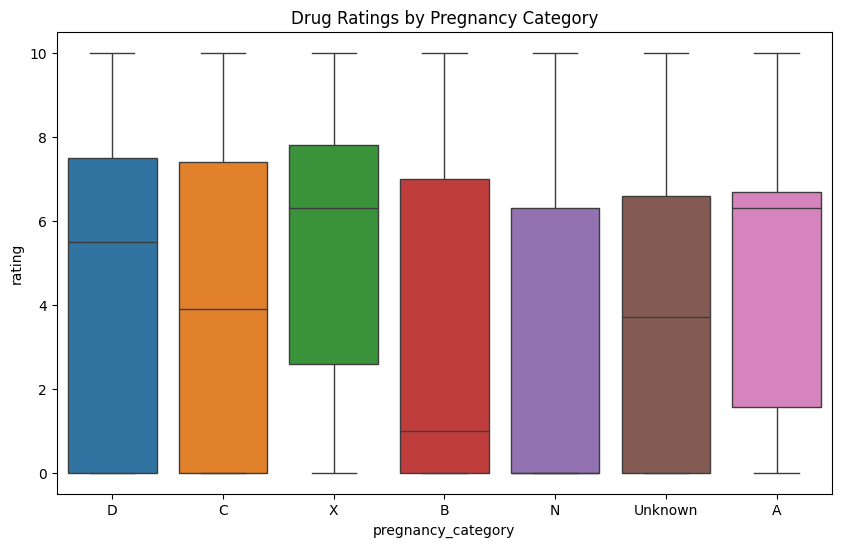

In [ ]:
#Boxplot of ratings by pregnancy category

plt.figure(figsize = (10,6))
sns.boxplot(data=data, x='pregnancy_category', y='rating', hue='pregnancy_category')
plt.title('Drug Ratings by Pregnancy Category')
plt.show()

In [ ]:
#Most common drugs for each condition

common_drugs = data.groupby('medical_condition')['drug_name'].value_counts().head(10)
print(common_drugs)

medical_condition  drug_name      
ADHD               Adderall           1
                   Adderall XR        1
                   Adhansia XR        1
                   Adzenys ER         1
                   Adzenys XR-ODT     1
                   Aptensio XR        1
                   Azstarys           1
                   Concerta           1
                   Cotempla XR-ODT    1
                   Daytrana           1
Name: count, dtype: int64


In [ ]:
#Side effects

side_effects = data['side_effects'].value_counts().head(10)
print(side_effects)

side_effects
Unknown                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         124
hives ; difficult breathing; swelling of your face, lips, tongue, or throat. This medicine may cause serious side effects. Stop using this medicine and call your doctor at once if you have: redness or swelling of the treated area; increased pain; or severe burning or skin irritation such as a rash, itching, pain, or blistering. Less serious side effects may be more likely, and you may hav

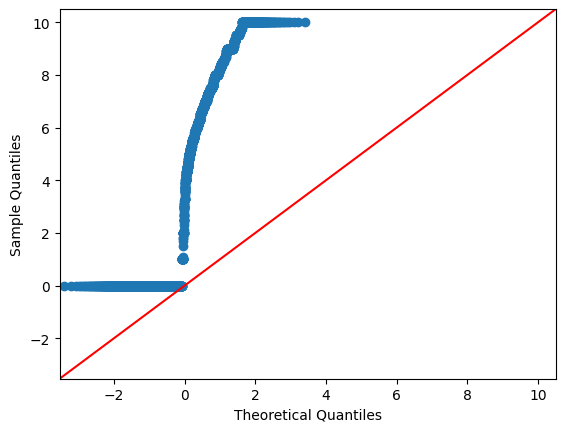

In [ ]:
#Confirming non-normality of ratings

import statsmodels.api as sm

fig = sm.qqplot(data['rating'], line = '45')
plt.show()

# Statistical Analysis

## Drug Ratings and Pregnancy Category

Performing non parametric tests because of non-normality

In [ ]:
import scipy.stats as stats

data_filtered = data[data['pregnancy_category'] != 'Unknown']

unique_categories = data_filtered['pregnancy_category'].unique()

# Create a list where each element is an array of ratings for a specific pregnancy category
ratings_by_category = [data_filtered[data_filtered['pregnancy_category'] == category]['rating'].values for category in unique_categories]


In [ ]:
#Performing Kruskal Wallis H test to determine if there are significant differences in median ratings across pregnancy categories
#H0: there is no difference in median ratings across pregnancy categories
#H1: there is a difference in the median ratings across pregnancy categories

result = stats.kruskal(*ratings_by_category)
print(result)

KruskalResult(statistic=np.float64(53.04293539086018), pvalue=np.float64(3.2957679179947593e-10))


Conclusion: obtaining a p value small enough to be rounded to zero indicates strong statistical significance, so we reject the null hypothesis and conclude that there is a statistically significant difference in median ratings across pregnancy categories.

# Drug Rating and Activity

In [ ]:
#dropping 0 values in both columns for analysis
data1 = data[(data['rating'] != 0) & (data['activity'] != '0%')]

In [ ]:
print(data1.shape)

(1343, 16)


In [ ]:
#performing spearman's rank correlation

rho, pvalue = stats.spearmanr(data1['rating'], data1['activity'])
print(f"Rho: {rho}")
print(f'p-value: {pvalue}')


Rho: -0.050736533123860277
p-value: 0.06305466953352697


Conclusion: The p value obtained is less than the threshold value of 0.05, so we are unable to say that there is a negative correlation between drug rating and activity. Rows with 0 were dropped to get a more accurate conclusion, but sample size was also reduced as a result.

# Pregnancy Category and Rx_OTC


Testing the relationship between pregnancy category and Rx_OTC status by using chi square test of independence

In [ ]:
#preparing data by dropping Unknown values

data_chi2 = data[(data['pregnancy_category'] != 'Unknown') & (data['rx_otc'] !='Unknown')]
print(data_chi2.shape)

(2701, 16)


In [ ]:
#performing chi square

contingency_table = pd.crosstab(data_chi2['pregnancy_category'], data_chi2['rx_otc'])

result = stats.chi2_contingency(contingency_table)

print(result)

Chi2ContingencyResult(statistic=np.float64(808.5088740509017), pvalue=np.float64(3.056641504299556e-167), dof=10, expected_freq=array([[  2.1392077 ,  11.83561644,   4.02517586],
       [ 60.49203999, 334.68493151, 113.82302851],
       [164.1247686 , 908.05479452, 308.82043688],
       [ 27.09663088, 149.91780822,  50.9855609 ],
       [ 51.81636431, 286.68493151,  97.49870418],
       [ 15.33098852,  84.82191781,  28.84709367]]))


Conclusion: The p value is much smaller than the threshold 0.05, so we reject the null hypothesis and conclude that there is a statistically significant relationship between pregnancy category and RX status

# Conclusions


*   The boxplot showed a difference in median ratings across different pregnancy categories.
*   Hives is the most common side effect in the dataset


*   The top 10 drugs are used for 3 conditions: Acne, herpes and ADHD.
*   Kruskall Wallis H test showed a statistically significant difference in median ratings between pregnancy categories


*   Spearman's rank correlation could not find a statistically significant relationship between rating and activity.
*   Chi square test of independence showed a statistically significant association between pregnancy category and Rx_otc







# Limitations


*   The small sample size limits generalizability and may not represent actual relationships or trends in the entire drugs.com dataset.
*   Large number of missing (na) values were imputed for EDA but excluded for statistical analysis, for better understanding of relationships. This limits generalizability and requires more rigorous imputation methods.

